In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

DATA_DIR    = r'D:\Tseng\圍棋\singletrials_timewindows'
PARIETAL_CH = ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
GROUPS      = ['master', 'amateur', 'prof']
COLORS      = {'master': 'steelblue', 'amateur': 'darkorange', 'prof': 'forestgreen'}

# 只需要 Alpha 取 RT1_ms 和 Rate（各頻帶相同）
df_raw = pd.read_csv(f'{DATA_DIR}\\Original_Alpha.csv')
df_raw['RT1_ms'] = pd.to_numeric(df_raw['RT1_ms'], errors='coerce')
df_raw['Rate']   = pd.to_numeric(df_raw['Rate'],   errors='coerce')

# 每個 trial 去重（取 Parietal 其中一個 channel 即可）
df_trials = (
    df_raw[df_raw['Channel'].isin(PARIETAL_CH)]
    .groupby(['Group', 'SubjectID', 'Session', 'Epoch'], as_index=False)[['RT1_ms', 'Rate']]
    .first()
    .dropna(subset=['RT1_ms', 'Rate'])
)

print('各 group trial 數：')
print(df_trials.groupby('Group').size())

各 group trial 數：
Group
amateur    2340
master     1826
prof        719
dtype: int64


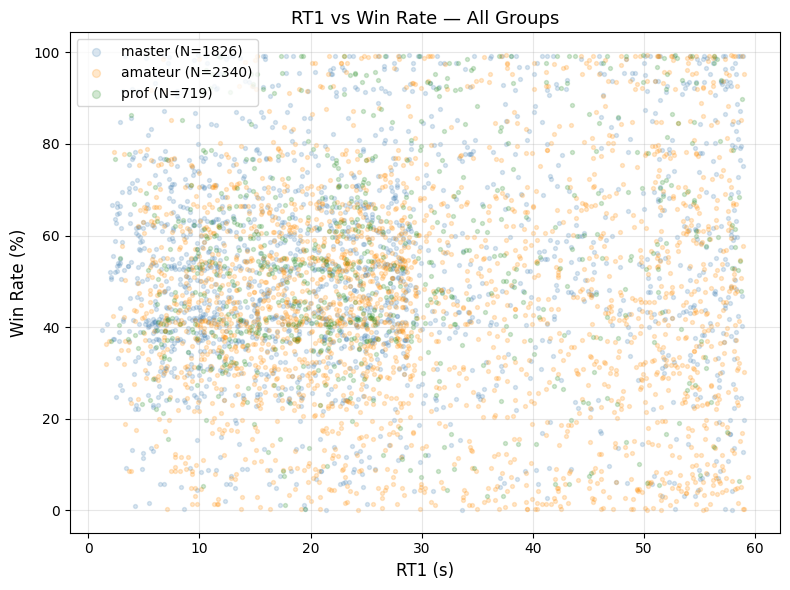

In [2]:
# ── 圖1：三個類別合在一張圖 ──
fig, ax = plt.subplots(figsize=(8, 6))

for g in GROUPS:
    df_g = df_trials[df_trials['Group'] == g]
    ax.scatter(df_g['RT1_ms'] / 1000, df_g['Rate'],
               alpha=0.2, s=8, color=COLORS[g], label=f'{g} (N={len(df_g)})')

ax.set_xlabel('RT1 (s)', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('RT1 vs Win Rate — All Groups', fontsize=13)
ax.legend(fontsize=10, markerscale=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\rt_winrate_all.png', dpi=150, bbox_inches='tight')
plt.show()

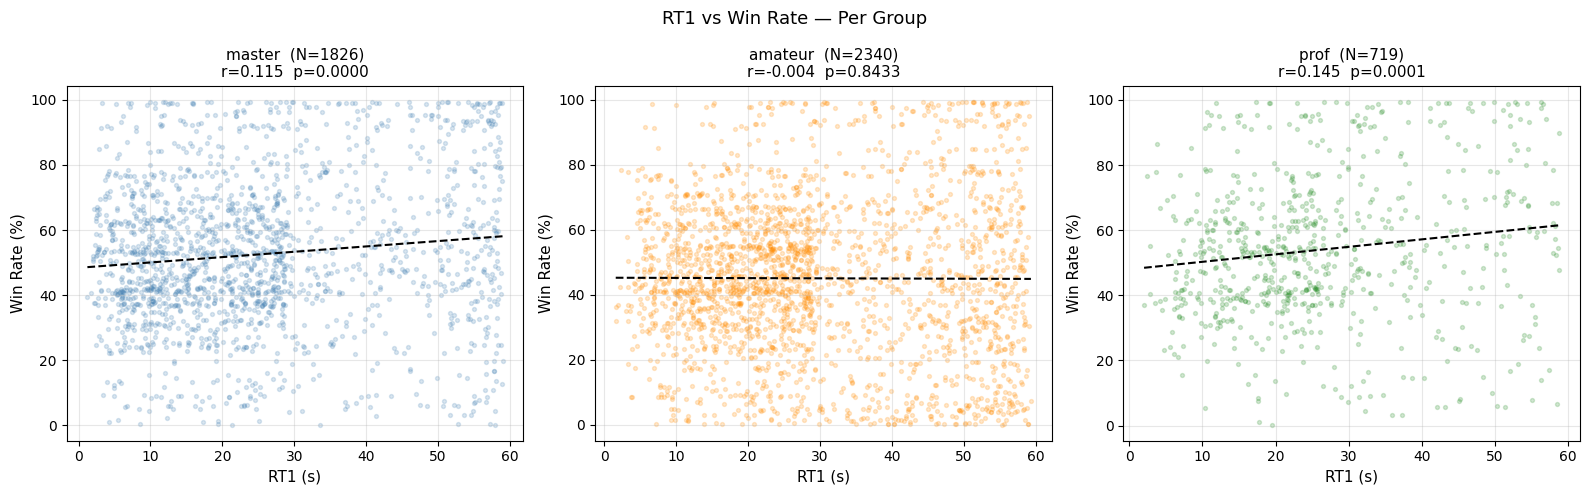

In [3]:
# ── 圖2：各類別分開畫（3 張，附相關係數）──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, g in zip(axes, GROUPS):
    df_g = df_trials[df_trials['Group'] == g]
    x = df_g['RT1_ms'].values / 1000
    y = df_g['Rate'].values

    ax.scatter(x, y, alpha=0.2, s=8, color=COLORS[g])

    # 趨勢線
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, p(x_line), color='black', lw=1.5, linestyle='--')

    r, pval = pearsonr(x, y)
    ax.set_title(f'{g}  (N={len(df_g)})\nr={r:.3f}  p={pval:.4f}', fontsize=11)
    ax.set_xlabel('RT1 (s)', fontsize=11)
    ax.set_ylabel('Win Rate (%)', fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('RT1 vs Win Rate — Per Group', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\rt_winrate_per_group.png', dpi=150, bbox_inches='tight')
plt.show()

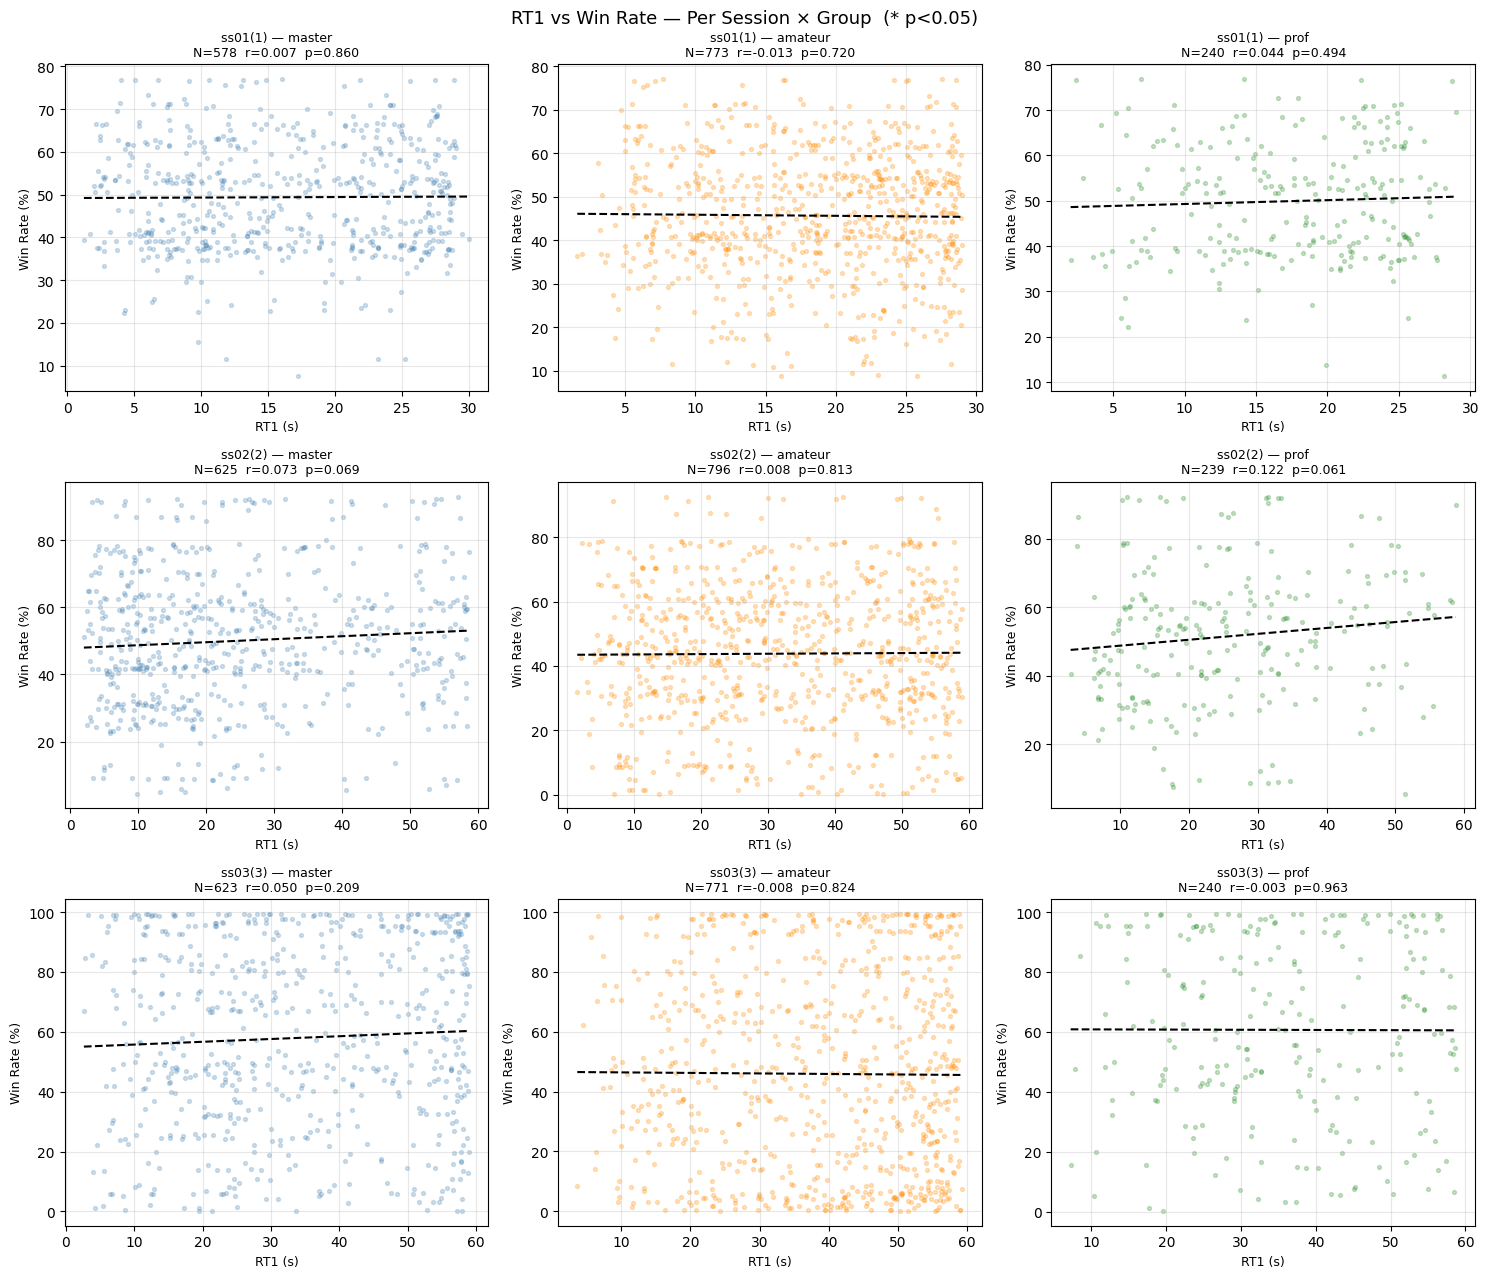

In [13]:
# ── 圖3：分 session × group（3 session × 3 group = 9 張）──
SESSIONS = ['ss01', 'ss02', 'ss03']
SESSION_LABEL = {'ss01': '1', 'ss02': '2', 'ss03': '3'}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row, ss in enumerate(SESSIONS):
    for col, g in enumerate(GROUPS):
        df_g = df_trials[(df_trials['Group'] == g) & (df_trials['Session'] == ss)]
        x = df_g['RT1_ms'].values / 1000
        y = df_g['Rate'].values
        ax = axes[row, col]

        ax.scatter(x, y, alpha=0.25, s=8, color=COLORS[g])

        if len(df_g) > 2:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, np.poly1d(z)(x_line), color='black', lw=1.5, linestyle='--')
            r, pval = pearsonr(x, y)
            sig = '*' if pval < 0.05 else ''
            ax.set_title(f'{ss}({SESSION_LABEL[ss]}) — {g}\nN={len(df_g)}  r={r:.3f}{sig}  p={pval:.3f}', fontsize=9)
        else:
            ax.set_title(f'{ss} — {g}\nN={len(df_g)} (資料不足)', fontsize=9)

        ax.set_xlabel('RT1 (s)', fontsize=9)
        ax.set_ylabel('Win Rate (%)', fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('RT1 vs Win Rate — Per Session × Group  (* p<0.05)', fontsize=13)
plt.tight_layout()
plt.savefig(r'd:\Tseng\game_eeg\RT1_ms_predict\rt_winrate_per_session_group.png', dpi=150, bbox_inches='tight')
plt.show()